# Closed-loop Bayesian test selection for Firebase Chat

This notebook compares One-Hot, TF-IDF with Truncated SVD, and Multilingual E5 on the same 69 Firebase Chat test cases.

The bug labels are fixed dummy values. They are not application test results or evidence of real defects. The Bayesian optimizer sees a label only after it selects that test case.


## Experiment flow

The notebook reads the QA workbook and checks all 69 cases. It first shows the nine known warm-start outcomes, one case per feature. Each representation then converts the same cases into its own numeric matrix. The experiment fits a Gaussian Process from the known outcomes, scores the untested candidates, selects one case, and reveals only that selected case's dummy result.

This process continues until every candidate has a position in the final order. The notebook compares only the three representation methods under the same warm start, dummy outcomes, cost-aware UCB rule, and stopping point.


In [1]:
# Install only missing packages. This works in Colab and on a local laptop.
import importlib.util
import os
import subprocess
import sys

RUN_E5 = os.getenv("BAYESIAN_NOTEBOOK_RUN_E5", "1") == "1"
required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "openpyxl": "openpyxl",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
if RUN_E5 and importlib.util.find_spec("sentence_transformers") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sentence-transformers"])

print("Environment ready. RUN_E5 =", RUN_E5)

Environment ready. RUN_E5 = True


In [2]:
from pathlib import Path
import json
import math
import re
import shutil
import warnings
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import FileLink, display

RANDOM_STATE = 42
KAPPA = 1.5
COST_EXPONENT = 0.5
E5_MODEL_NAME = "intfloat/multilingual-e5-large-instruct"
AUTO_DOWNLOAD_IN_COLAB = False
DUMMY_FAULT_THEMES = {
    "message_delivery_and_read_state": [
        "FC-MN-006", "FC-MN-007", "FC-CRP-007", "FC-CRP-008",
        "FC-CRG-004", "FC-CRG-007", "FC-MIF-001", "FC-MIF-002", "FC-MIF-003",
    ],
    "group_membership_permission": [
        "FC-NCP-004", "FC-NCP-005", "FC-GPR-002", "FC-GPR-003",
    ],
}
DUMMY_BUG_IDS = sorted({tcs_id for ids_in_theme in DUMMY_FAULT_THEMES.values() for tcs_id in ids_in_theme})

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(RANDOM_STATE)
print(f"Controlled dummy oracle: {len(DUMMY_BUG_IDS)} dummy bugs in {len(DUMMY_FAULT_THEMES)} fault themes")
print(f"Cost-aware UCB: kappa={KAPPA}, cost exponent={COST_EXPONENT}")

Controlled dummy oracle: 13 dummy bugs in 2 fault themes
Cost-aware UCB: kappa=1.5, cost exponent=0.5


## 1. Load and validate the QA workbook

On a local laptop, the notebook searches the current folder and its parents for scenarios/firebase_chat/scenario.xlsx. In Colab, it opens a file upload dialog when the workbook is not available.

In [3]:
import re
from pathlib import Path
import numpy as np
import pandas as pd


def parse_minutes(value) -> float:
    """Extract the first numeric duration from the QA Time Testing cell."""
    match = re.search(r"\d+(?:\.\d+)?", str(value))
    if not match:
        raise ValueError(f"Cannot parse Time Testing value: {value!r}")
    return float(match.group())


def choose_initial_seed(cases: pd.DataFrame) -> list[int]:
    """Choose the lexicographically first TCS ID from every Menu."""
    ordered = cases.reset_index().sort_values(["Menu", "TCS ID"], kind="stable")
    return sorted(ordered.groupby("Menu", sort=True).head(1)["index"].tolist())


def find_workbook() -> Path:
    checked = []
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "scenarios" / "firebase_chat" / "scenario.xlsx"
        checked.append(candidate)
        if candidate.exists():
            return candidate.resolve()

    try:
        from google.colab import files
    except ImportError as exc:
        locations = "\n".join(str(path) for path in checked)
        raise FileNotFoundError(
            "scenario.xlsx was not found. Run from the MAS AI repository or copy the workbook "
            f"to scenarios/firebase_chat/scenario.xlsx. Checked:\n{locations}"
        ) from exc

    print("Upload scenario.xlsx from scenarios/firebase_chat/")
    uploaded = files.upload()
    if not uploaded:
        raise FileNotFoundError("No workbook was uploaded.")
    uploaded_name = next(iter(uploaded))
    return Path(uploaded_name).resolve()


def load_qa_cases(workbook: Path) -> pd.DataFrame:
    raw = pd.read_excel(workbook, header=None)
    matches = np.argwhere(raw.eq("TCS ID").to_numpy())
    if len(matches) == 0:
        raise ValueError("Could not locate the TCS ID header in the workbook.")
    header_row = int(matches[0, 0])
    cases = pd.read_excel(workbook, header=header_row)
    required_columns = [
        "TCS ID", "Menu", "Submenu 1", "Submenu 2", "Test Case Scenario",
        "Test Step", "Expected Result", "Test Type", "User", "Time Testing",
    ]
    missing_columns = [column for column in required_columns if column not in cases.columns]
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")
    cases = cases.loc[cases["TCS ID"].astype(str).str.startswith("FC-")].copy()
    cases = cases[required_columns].reset_index(drop=True)
    text_columns = [column for column in required_columns if column != "Time Testing"]
    cases[text_columns] = cases[text_columns].fillna("").astype(str)
    cases["estimated_cost"] = cases["Time Testing"].map(parse_minutes)
    if cases["TCS ID"].duplicated().any():
        duplicates = cases.loc[cases["TCS ID"].duplicated(), "TCS ID"].tolist()
        raise ValueError(f"Duplicate TCS IDs: {duplicates}")
    return cases


In [4]:
WORKBOOK_PATH = find_workbook()
cases = load_qa_cases(WORKBOOK_PATH)
if len(cases) != 69:
    raise ValueError(f"This experiment expects 69 Firebase Chat cases, found {len(cases)}.")

unknown_bug_ids = sorted(set(DUMMY_BUG_IDS) - set(cases["TCS ID"]))
if unknown_bug_ids:
    raise ValueError(f"DUMMY_BUG_IDS not found in workbook: {unknown_bug_ids}")

oracle = cases["TCS ID"].isin(DUMMY_BUG_IDS).astype(int).to_numpy()
fault_theme_by_id = {
    tcs_id: theme
    for theme, ids_in_theme in DUMMY_FAULT_THEMES.items()
    for tcs_id in ids_in_theme
}
costs = cases["estimated_cost"].to_numpy(dtype=float)
initial_indices = choose_initial_seed(cases)
warm_start_bug_count = int(oracle[initial_indices].sum())
assert warm_start_bug_count >= 1
ids = cases["TCS ID"].to_numpy()
menus = cases["Menu"].to_numpy()

repo_root = WORKBOOK_PATH.parents[2] if WORKBOOK_PATH.parent.name == "firebase_chat" else Path.cwd()
if (repo_root / "scenarios" / "firebase_chat" / "scenario.xlsx").exists():
    RESULT_DIR = repo_root / "experiment" / "bayesian" / "results"
else:
    RESULT_DIR = Path.cwd() / "experiment" / "bayesian" / "results"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("Workbook:", WORKBOOK_PATH)
print("Cases:", len(cases), "| Menus/features:", cases["Menu"].nunique())
print("Warm start:", len(initial_indices), "known historical outcomes, one per Menu")
print("Warm-start dummy bugs:", warm_start_bug_count, "| warm-start passes:", len(initial_indices) - warm_start_bug_count)
print("Total estimated cost:", costs.sum(), "minutes")
fault_theme_table = cases.loc[cases["TCS ID"].isin(DUMMY_BUG_IDS), ["TCS ID", "Menu", "Test Case Scenario"]].copy()
fault_theme_table["dummy_fault_theme"] = fault_theme_table["TCS ID"].map(fault_theme_by_id)
display(fault_theme_table.sort_values(["dummy_fault_theme", "TCS ID"]).reset_index(drop=True))

Workbook: C:\Users\radit\Project\VisualStudioProject\Skripsi\MAS AI\scenarios\firebase_chat\scenario.xlsx
Cases: 69 | Menus/features: 9
Warm start: 9 known historical outcomes, one per Menu
Warm-start dummy bugs: 1 | warm-start passes: 8
Total estimated cost: 632.0 minutes


,TCS ID,Menu,Test Case Scenario,dummy_fault_theme
0,FC-GPR-002,Profil Grup,"Tombol ""Add Participant"" tampil bagi pembuat grup",group_membership_permission
1,FC-GPR-003,Profil Grup,"Tombol ""Add Participant"" tidak tampil bagi ang...",group_membership_permission
2,FC-NCP-004,Buat Chat Baru,Menambahkan partisipan baru ke grup yang sudah...,group_membership_permission
3,FC-NCP-005,Buat Chat Baru,"Daftar pengguna pada mode ""Add Participant"" ti...",group_membership_permission
4,FC-CRG-004,Ruang Obrolan,"Status pesan menjadi ""read"" hanya setelah selu...",message_delivery_and_read_state
5,FC-CRG-007,Ruang Obrolan,Jumlah pesan belum dibaca (unread) direset saa...,message_delivery_and_read_state
6,FC-CRP-007,Ruang Obrolan,Pesan yang diterima otomatis ditandai sudah di...,message_delivery_and_read_state
7,FC-CRP-008,Ruang Obrolan,Melihat info pengiriman (Delivered/Read) pada ...,message_delivery_and_read_state
8,FC-MIF-001,Info Pesan,Menampilkan waktu Delivered dan Read pada perc...,message_delivery_and_read_state
9,FC-MIF-002,Info Pesan,"Status ""Delivered"" terisi sebelum status ""Read...",message_delivery_and_read_state


## 2. Warm-start results before Bayesian selection

Bayesian Optimization cannot make its first informed choice without any previous result. The experiment therefore begins with nine already known outcomes, one QA case from each Menu. These are the only labels known before the optimizer chooses test #10.


In [5]:
warm_start_table = cases.iloc[initial_indices][[
    "TCS ID", "Menu", "Test Case Scenario", "Test Step", "Expected Result", "estimated_cost",
]].copy()
warm_start_table["known_outcome"] = np.where(
    oracle[initial_indices].astype(bool), "Dummy bug", "Pass"
)
warm_start_table["dummy_fault_theme"] = warm_start_table["TCS ID"].map(fault_theme_by_id).fillna("-")
warm_start_table = warm_start_table.sort_values(["Menu", "TCS ID"]).reset_index(drop=True)
display(warm_start_table)


,TCS ID,Menu,Test Case Scenario,Test Step,Expected Result,estimated_cost,known_outcome,dummy_fault_theme
0,FC-NCG-001,Buat Chat Baru,Membuat grup baru dengan nama grup dan foto valid,1. Pilih minimal 1 partisipan pada halaman Pil...,1. Grup baru berhasil dibuat dan langsung tamp...,11.0,Pass,-
1,FC-MIF-001,Info Pesan,Menampilkan waktu Delivered dan Read pada perc...,1. Kirim pesan pada ruang obrolan personal\n2....,1. Menampilkan waktu Delivered dan waktu Read ...,5.0,Dummy bug,message_delivery_and_read_state
2,FC-FSI-001,Lihat Gambar Layar Penuh,Menampilkan gambar resolusi penuh beserta capt...,1. Buka ruang obrolan yang memiliki pesan berg...,1. Gambar tampil dalam resolusi penuh satu lay...,6.0,Pass,-
3,FC-LGN-001,Login,Login berhasil dengan email dan password yang ...,1. Buka aplikasi Firebase Chat\n2. Masukkan em...,"1. Menampilkan Toast ""Login Success""\n2. User ...",13.0,Pass,-
4,FC-MN-001,Main,Menampilkan daftar percakapan diurutkan dari p...,1. Login ke dalam aplikasi dengan akun yang me...,1. Percakapan dengan pesan terakhir paling bar...,9.0,Pass,-
5,FC-GPR-001,Profil Grup,"Menampilkan informasi grup (avatar, nama, juml...",1. Buka Profil Grup dari ruang obrolan grup,"1. Menampilkan avatar grup, nama grup, ""Partic...",7.0,Pass,-
6,FC-PRF-001,Profil Pengguna,Menampilkan profil pengguna lain (lawan bicara),1. Buka ruang obrolan personal\n2. Tekan avata...,"1. Menampilkan avatar, nama, dan email milik l...",6.0,Pass,-
7,FC-REG-001,Register,Registrasi akun baru berhasil dengan data valid,"1. Buka halaman Register\n2. Isi Nama, Email, ...",1. Akun baru berhasil dibuat pada Firebase Aut...,5.0,Pass,-
8,FC-CRG-001,Ruang Obrolan,Mengirim pesan teks dalam ruang obrolan grup,"1. Buka ruang obrolan grup\n2. Ketik pesan, te...",1. Pesan tampil pada ruang obrolan lengkap den...,6.0,Pass,-


## 3. All fixed dummy bugs for researcher inspection

The table below explains where the 13 fixed dummy bugs are placed and what each case checks. It is visible only for understanding the controlled experiment. The surrogate model never receives this full table as training data.


In [6]:
dummy_bug_table = cases.loc[cases["TCS ID"].isin(DUMMY_BUG_IDS), [
    "TCS ID", "Menu", "Test Case Scenario", "Test Step", "Expected Result", "estimated_cost",
]].copy()
dummy_bug_table["dummy_fault_theme"] = dummy_bug_table["TCS ID"].map(fault_theme_by_id)
dummy_bug_table = dummy_bug_table.sort_values(["dummy_fault_theme", "TCS ID"]).reset_index(drop=True)
display(dummy_bug_table)


,TCS ID,Menu,Test Case Scenario,Test Step,Expected Result,estimated_cost,dummy_fault_theme
0,FC-GPR-002,Profil Grup,"Tombol ""Add Participant"" tampil bagi pembuat grup",1. Buka Profil Grup sebagai user yang membuat ...,"1. Tombol ""Add Participant"" tampil dan dapat d...",2.0,group_membership_permission
1,FC-GPR-003,Profil Grup,"Tombol ""Add Participant"" tidak tampil bagi ang...",1. Buka Profil Grup sebagai anggota yang bukan...,"1. Tombol ""Add Participant"" tidak ditampilkan",7.0,group_membership_permission
2,FC-NCP-004,Buat Chat Baru,Menambahkan partisipan baru ke grup yang sudah...,1. Buka Profil Grup sebagai pembuat grup\n2. T...,"1. Menampilkan Toast ""Success Adding new Parti...",2.0,group_membership_permission
3,FC-NCP-005,Buat Chat Baru,"Daftar pengguna pada mode ""Add Participant"" ti...",1. Buka Profil Grup sebagai pembuat grup\n2. T...,1. User yang sudah menjadi anggota grup tidak ...,11.0,group_membership_permission
4,FC-CRG-004,Ruang Obrolan,"Status pesan menjadi ""read"" hanya setelah selu...",1. Kirim pesan pada grup beranggotakan lebih d...,"1. Status pesan tetap centang tunggal (belum ""...",8.0,message_delivery_and_read_state
5,FC-CRG-007,Ruang Obrolan,Jumlah pesan belum dibaca (unread) direset saa...,1. Buka ruang obrolan grup yang memiliki pesan...,1. Badge unread untuk grup tersebut hilang/men...,8.0,message_delivery_and_read_state
6,FC-CRP-007,Ruang Obrolan,Pesan yang diterima otomatis ditandai sudah di...,1. User B mengirim pesan ke User A saat User A...,1. Seluruh pesan yang termuat langsung berstat...,13.0,message_delivery_and_read_state
7,FC-CRP-008,Ruang Obrolan,Melihat info pengiriman (Delivered/Read) pada ...,1. Kirim pesan pada ruang obrolan personal\n2....,1. Menampilkan halaman Info Pesan dengan waktu...,13.0,message_delivery_and_read_state
8,FC-MIF-001,Info Pesan,Menampilkan waktu Delivered dan Read pada perc...,1. Kirim pesan pada ruang obrolan personal\n2....,1. Menampilkan waktu Delivered dan waktu Read ...,5.0,message_delivery_and_read_state
9,FC-MIF-002,Info Pesan,"Status ""Delivered"" terisi sebelum status ""Read...","1. Kirim pesan pada ruang obrolan personal, tu...",1. Waktu Delivered terisi terlebih dahulu sesa...,10.0,message_delivery_and_read_state


## 4. Fixed dummy outcomes

The experiment uses one fixed synthetic oracle with two fault themes: message delivery and read state, plus group membership permission. Every method faces exactly the same oracle. The full mapping is visible to the researcher, but the surrogate model does not receive it.

The warm start contains one test from each Menu and represents known historical outcomes. It contains at least one dummy bug without selecting the warm-start cases from oracle labels. After that point, the surrogate receives outcomes only after it selects a test. The fixed Excel order is used later only to place discrete candidates on a readable horizontal axis.

In [7]:
x_display = np.arange(len(cases))
print(f"The fixed oracle contains {int(oracle.sum())} dummy bugs across {len(oracle)} test cases.")

The fixed oracle contains 13 dummy bugs across 69 test cases.


## 5. Independent representation matrices

Each method converts the workbook into its own matrix. The matrices are never combined:

- One-Hot encodes fields such as Menu, Submenu, Test Type, and User.
- TF-IDF uses words and bigrams from the scenario, steps, and expected result. Truncated SVD reduces this matrix to 16 numeric dimensions.
- Multilingual E5 creates semantic embeddings from the same labeled text. It runs locally in the Colab runtime and does not require a paid API.

In [8]:
TEXT_FIELDS = [
    "Menu", "Submenu 1", "Submenu 2", "Test Case Scenario", "Test Step",
    "Expected Result", "Test Type", "User",
]
CATEGORICAL_FIELDS = ["Menu", "Submenu 1", "Submenu 2", "Test Type", "User"]


def serialize_cases(frame: pd.DataFrame) -> list[str]:
    return [
        "\n".join(f"{field}: {row[field]}" for field in TEXT_FIELDS)
        for _, row in frame.iterrows()
    ]


def normalize_rows(matrix: np.ndarray) -> np.ndarray:
    matrix = np.asarray(matrix, dtype=float)
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    return matrix / np.where(norms == 0, 1.0, norms)


def build_one_hot(frame: pd.DataFrame) -> np.ndarray:
    encoded = pd.get_dummies(frame[CATEGORICAL_FIELDS].astype(str), dtype=float)
    return normalize_rows(encoded.to_numpy())


def tokenize_with_bigrams(text: str) -> list[str]:
    tokens = re.findall(r"(?u)\b\w\w+\b", text.lower())
    return tokens + [f"{left}__{right}" for left, right in zip(tokens, tokens[1:])]


def build_tfidf_svd(frame: pd.DataFrame, random_state: int = 42) -> tuple[np.ndarray, list[str], np.ndarray]:
    documents = [tokenize_with_bigrams(text) for text in serialize_cases(frame)]
    vocabulary = sorted({token for document in documents for token in document})
    token_to_column = {token: column for column, token in enumerate(vocabulary)}
    counts = np.zeros((len(documents), len(vocabulary)), dtype=float)
    document_frequency = np.zeros(len(vocabulary), dtype=float)
    for row, document in enumerate(documents):
        for token in document:
            counts[row, token_to_column[token]] += 1.0
        for token in set(document):
            document_frequency[token_to_column[token]] += 1.0
    sublinear_tf = np.where(counts > 0, 1.0 + np.log(np.maximum(counts, 1.0)), 0.0)
    inverse_document_frequency = np.log((1.0 + len(documents)) / (1.0 + document_frequency)) + 1.0
    tfidf = normalize_rows(sublinear_tf * inverse_document_frequency)
    components = min(16, tfidf.shape[0] - 1, tfidf.shape[1] - 1)
    left_vectors, singular_values, right_vectors = np.linalg.svd(tfidf, full_matrices=False)
    dense = left_vectors[:, :components] * singular_values[:components]
    return normalize_rows(dense), vocabulary, right_vectors[:components]


def build_e5(frame: pd.DataFrame, model_name: str, result_dir: Path) -> np.ndarray:
    from sentence_transformers import SentenceTransformer

    instruction = (
        "Represent this Android QA test case so cases exercising similar features, "
        "actions, and expected behaviors are close."
    )
    inputs = [f"Instruct: {instruction}\nQuery: {text}" for text in serialize_cases(frame)]
    model = SentenceTransformer(model_name)
    embeddings = model.encode(
        inputs,
        normalize_embeddings=True,
        show_progress_bar=True,
        convert_to_numpy=True,
    )
    np.save(result_dir / "e5_embeddings.npy", embeddings)
    return embeddings


one_hot_matrix = build_one_hot(cases)
tfidf_svd_matrix, tfidf_vocabulary, tfidf_components = build_tfidf_svd(cases, RANDOM_STATE)
representations = {
    "One-Hot": one_hot_matrix,
    "TF-IDF + SVD": tfidf_svd_matrix,
}
if RUN_E5:
    representations["Multilingual E5"] = build_e5(cases, E5_MODEL_NAME, RESULT_DIR)
else:
    print("Multilingual E5 skipped only because BAYESIAN_NOTEBOOK_RUN_E5=0.")

for name, matrix in representations.items():
    assert matrix.shape[0] == len(cases), f"{name} row mismatch"
    assert np.isfinite(matrix).all(), f"{name} contains non-finite values"
    print(f"{name:20s} -> {matrix.shape}")

C:\Users\radit\Project\VisualStudioProject\Skripsi\MAS AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:  33%|███▎      | 1/3 [00:01<00:03,  1.67s/it]

Batches:  67%|██████▋   | 2/3 [00:02<00:01,  1.20s/it]

Batches: 100%|██████████| 3/3 [00:02<00:00,  1.41it/s]

Batches: 100%|██████████| 3/3 [00:02<00:00,  1.12it/s]

One-Hot              -> (69, 89)
TF-IDF + SVD         -> (69, 16)
Multilingual E5      -> (69, 1024)


## 6. Closed-loop Bayesian selection

The first experiment uses Gaussian Process Regression as a transparent surrogate. The dummy outcome is binary, so this model is an initial approximation rather than a validated final classifier.

The run starts from the known warm-start outcomes. It then selects the next untested candidate with cost-aware UCB:

utility = clipped_mean + kappa × uncertainty

acquisition = utility / cost^cost_exponent

The notebook uses kappa = 1.5 and a square-root cost penalty. The predicted mean favors candidates that may expose a bug. Uncertainty lets the optimizer explore less familiar cases. Dividing by cost gives a mild preference to shorter tests.

In [9]:
import numpy as np
import pandas as pd


def _squared_distances(left: np.ndarray, right: np.ndarray) -> np.ndarray:
    return np.maximum(
        np.sum(left * left, axis=1)[:, None]
        + np.sum(right * right, axis=1)[None, :]
        - 2.0 * left @ right.T,
        0.0,
    )


def _gp_predict(train_x, train_y, candidate_x, length_scale=1.0, noise=1e-3):
    """Fixed-kernel Gaussian Process posterior implemented with NumPy."""
    train_x = np.asarray(train_x, dtype=float)
    candidate_x = np.asarray(candidate_x, dtype=float)
    train_y = np.asarray(train_y, dtype=float)
    train_kernel = np.exp(-0.5 * _squared_distances(train_x, train_x) / length_scale**2)
    train_kernel += (noise + 1e-8) * np.eye(len(train_x))
    cross_kernel = np.exp(-0.5 * _squared_distances(train_x, candidate_x) / length_scale**2)
    cholesky = np.linalg.cholesky(train_kernel)
    weights = np.linalg.solve(cholesky.T, np.linalg.solve(cholesky, train_y))
    mean = cross_kernel.T @ weights
    projected = np.linalg.solve(cholesky, cross_kernel)
    variance = np.maximum(1.0 - np.sum(projected * projected, axis=0), 1e-12)
    return mean, np.sqrt(variance)


def _finalize_order(rows: list[dict]) -> pd.DataFrame:
    result = pd.DataFrame(rows)
    result["execution_position"] = np.arange(1, len(result) + 1)
    result["cumulative_bugs"] = result["confirmed_bug_dummy"].cumsum()
    result["cumulative_cost"] = result["estimated_cost"].cumsum()
    return result[
        [
            "execution_position", "tcs_id", "menu", "estimated_cost",
            "is_initial_seed", "predicted_mean", "predicted_std", "acquisition",
            "confirmed_bug_dummy", "cumulative_bugs", "cumulative_cost",
        ]
    ]


def run_closed_loop(
    matrix,
    ids,
    menus,
    costs,
    oracle,
    initial_indices,
    kappa=1.5,
    cost_exponent=0.5,
    snapshot_counts=None,
    random_state=42,
):
    """Return a full order while revealing only selected oracle labels."""
    matrix = np.asarray(matrix, dtype=float)
    ids = np.asarray(ids, dtype=str)
    menus = np.asarray(menus, dtype=str)
    costs = np.asarray(costs, dtype=float)
    oracle = np.asarray(oracle, dtype=int)
    if not (len(matrix) == len(ids) == len(menus) == len(costs) == len(oracle)):
        raise ValueError("matrix, ids, menus, costs, and oracle must have equal lengths")
    if np.any(costs <= 0):
        raise ValueError("All estimated costs must be positive")

    revealed = list(dict.fromkeys(int(index) for index in initial_indices))
    if not revealed:
        raise ValueError("At least one initial test is required")
    snapshot_counts = set(snapshot_counts or [])
    audit = []
    snapshots = []
    rows = [
        {
            "tcs_id": ids[index],
            "menu": menus[index],
            "estimated_cost": costs[index],
            "is_initial_seed": True,
            "predicted_mean": np.nan,
            "predicted_std": np.nan,
            "acquisition": np.nan,
            "confirmed_bug_dummy": int(oracle[index]),
        }
        for index in revealed
    ]

    while len(revealed) < len(ids):
        training_indices = list(revealed)
        mean, std = _gp_predict(matrix[training_indices], oracle[training_indices], matrix)

        remaining = np.array([index for index in range(len(ids)) if index not in set(revealed)], dtype=int)
        utility = np.clip(mean, 0.0, 1.0) + kappa * std
        acquisition = np.full(len(ids), np.nan, dtype=float)
        acquisition[remaining] = utility[remaining] / np.power(
            np.maximum(costs[remaining], 1.0), cost_exponent
        )
        best_value = np.nanmax(acquisition[remaining])
        tied = remaining[np.isclose(acquisition[remaining], best_value)]
        selected = int(min(tied, key=lambda index: ids[index]))

        audit.append(
            {
                "train_count": len(training_indices),
                "revealed_count": len(revealed),
                "training_indices": list(training_indices),
                "revealed_indices": list(revealed),
                "selected_index": selected,
            }
        )
        if len(revealed) in snapshot_counts:
            snapshots.append(
                {
                    "tested_count": len(revealed),
                    "observed_indices": list(revealed),
                    "selected_index": selected,
                    "mean": mean.copy(),
                    "std": std.copy(),
                    "acquisition": acquisition.copy(),
                }
            )

        rows.append(
            {
                "tcs_id": ids[selected],
                "menu": menus[selected],
                "estimated_cost": costs[selected],
                "is_initial_seed": False,
                "predicted_mean": float(mean[selected]),
                "predicted_std": float(std[selected]),
                "acquisition": float(acquisition[selected]),
                "confirmed_bug_dummy": int(oracle[selected]),
            }
        )
        revealed.append(selected)

    return _finalize_order(rows), audit, snapshots



## 7. How each method chooses test #10

All three methods receive the same nine warm-start outcomes. They differ only in how they judge similarity between an untested case and the known cases. One-Hot uses matching category values. TF-IDF + SVD uses repeated words and word pairs from the scenario, steps, and expected result. Multilingual E5 uses the meaning of the same text.

The table below shows each method's first candidate after warm start. Its final score is the cost-aware UCB score, so a candidate is preferred when it has a promising predicted result, useful uncertainty, and lower estimated test time.


In [10]:
method_reasoning = pd.DataFrame([
    {"method": "One-Hot", "what_it_compares": "Matching Menu, submenu, test type, and user categories"},
    {"method": "TF-IDF + SVD", "what_it_compares": "Shared words and word pairs in scenario, steps, and expected result"},
    {"method": "Multilingual E5", "what_it_compares": "Semantic meaning of the full labelled test-case text"},
])
display(method_reasoning)

first_choice_rows = []
remaining_after_warm_start = np.array([
    index for index in range(len(cases)) if index not in set(initial_indices)
])
for method_name, matrix in representations.items():
    mean, std = _gp_predict(matrix[initial_indices], oracle[initial_indices], matrix)
    utility = np.clip(mean, 0.0, 1.0) + KAPPA * std
    acquisition = utility / np.power(np.maximum(costs, 1.0), COST_EXPONENT)
    selected = int(remaining_after_warm_start[np.argmax(acquisition[remaining_after_warm_start])])
    first_choice_rows.append({
        "method": method_name,
        "test_10_candidate": ids[selected],
        "menu": menus[selected],
        "predicted_mean": float(np.clip(mean[selected], 0.0, 1.0)),
        "uncertainty": float(std[selected]),
        "estimated_cost_minutes": float(costs[selected]),
        "cost_aware_ucb_score": float(acquisition[selected]),
    })
first_choice_table = pd.DataFrame(first_choice_rows)
display(first_choice_table.style.format({
    "predicted_mean": "{:.3f}", "uncertainty": "{:.3f}",
    "estimated_cost_minutes": "{:.1f}", "cost_aware_ucb_score": "{:.3f}",
}))


,method,what_it_compares
0,One-Hot,"Matching Menu, submenu, test type, and user ca..."
1,TF-IDF + SVD,"Shared words and word pairs in scenario, steps..."
2,Multilingual E5,Semantic meaning of the full labelled test-cas...


,method,test_10_candidate,menu,predicted_mean,uncertainty,estimated_cost_minutes,cost_aware_ucb_score
0,One-Hot,FC-NCP-004,Buat Chat Baru,0.032,0.774,2.0,0.844
1,TF-IDF + SVD,FC-NCP-004,Buat Chat Baru,0.069,0.746,2.0,0.840
2,Multilingual E5,FC-MN-006,Main,0.417,0.292,2.0,0.605


## 8. Run the closed-loop Bayesian selection

Each method now continues from the same warm start. It selects one untested case, receives that case's dummy outcome, updates its Gaussian Process, and makes the next choice.


In [11]:
snapshot_counts = {
    len(initial_indices),
    min(len(cases) - 1, len(initial_indices) + 5),
    min(len(cases) - 1, len(initial_indices) + 15),
    min(len(cases) - 1, len(initial_indices) + 30),
}

runs = {}
audits = {}
snapshots_by_method = {}
for method_name, matrix in representations.items():
    run, audit, snapshots = run_closed_loop(
        matrix=matrix,
        ids=ids,
        menus=menus,
        costs=costs,
        oracle=oracle,
        initial_indices=initial_indices,
        kappa=KAPPA,
        cost_exponent=COST_EXPONENT,
        snapshot_counts=snapshot_counts,
        random_state=RANDOM_STATE,
    )
    runs[method_name] = run
    audits[method_name] = audit
    snapshots_by_method[method_name] = snapshots


for method_name, run in runs.items():
    assert set(run["tcs_id"]) == set(cases["TCS ID"])
    assert run["tcs_id"].is_unique
    assert run["cumulative_bugs"].is_monotonic_increasing
    assert run["cumulative_cost"].is_monotonic_increasing
    assert int(run["cumulative_bugs"].iloc[-1]) == int(oracle.sum())
    print(f"{method_name:20s}: first dummy bug at test #{int(run.loc[run['confirmed_bug_dummy'].eq(1), 'execution_position'].min())}")


One-Hot             : first dummy bug at test #7
TF-IDF + SVD        : first dummy bug at test #7
Multilingual E5     : first dummy bug at test #7


## 9. Convergence plot

This chart shows how many dummy bugs each method has found after each executed test. A curve that rises earlier has found more of the fixed dummy bugs with fewer test executions. Random selection provides a baseline.

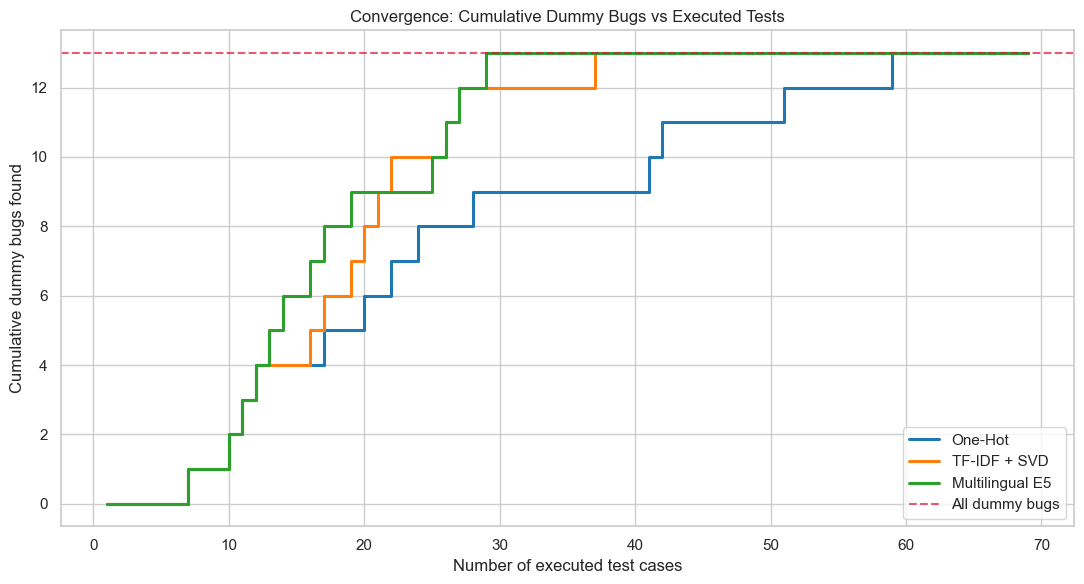

In [12]:
colors = {
    "One-Hot": "#1f77b4",
    "TF-IDF + SVD": "#ff7f0e",
    "Multilingual E5": "#2ca02c",
}

fig, ax = plt.subplots(figsize=(11, 6))
for method_name, run in runs.items():
    ax.step(run["execution_position"], run["cumulative_bugs"], where="post",
            linewidth=2.2, color=colors.get(method_name), label=method_name)

ax.axhline(oracle.sum(), color="crimson", linestyle="--", alpha=0.7, label="All dummy bugs")
ax.set(title="Convergence: Cumulative Dummy Bugs vs Executed Tests",
       xlabel="Number of executed test cases", ylabel="Cumulative dummy bugs found")
ax.legend()
fig.tight_layout()
fig.savefig(RESULT_DIR / "convergence.png", dpi=180, bbox_inches="tight")
plt.show()

## 10. Snapshot setup

The next figure uses the fixed Excel order to place the 69 discrete candidates on one readable axis. Connecting lines are visual guides. They do not turn the test cases into a continuous objective function.

In [13]:
print("Snapshot counts:", sorted(snapshot_counts))

Snapshot counts: [9, 14, 24, 39]


## 11. Posterior and acquisition snapshots

Each Bayesian representation gets its own figure. The left column shows the fixed dummy truth, the Gaussian Process mean, its uncertainty band, and the outcomes revealed so far. The right column shows the acquisition score used to choose the next test.

The figures below only compare the three Bayesian representations.

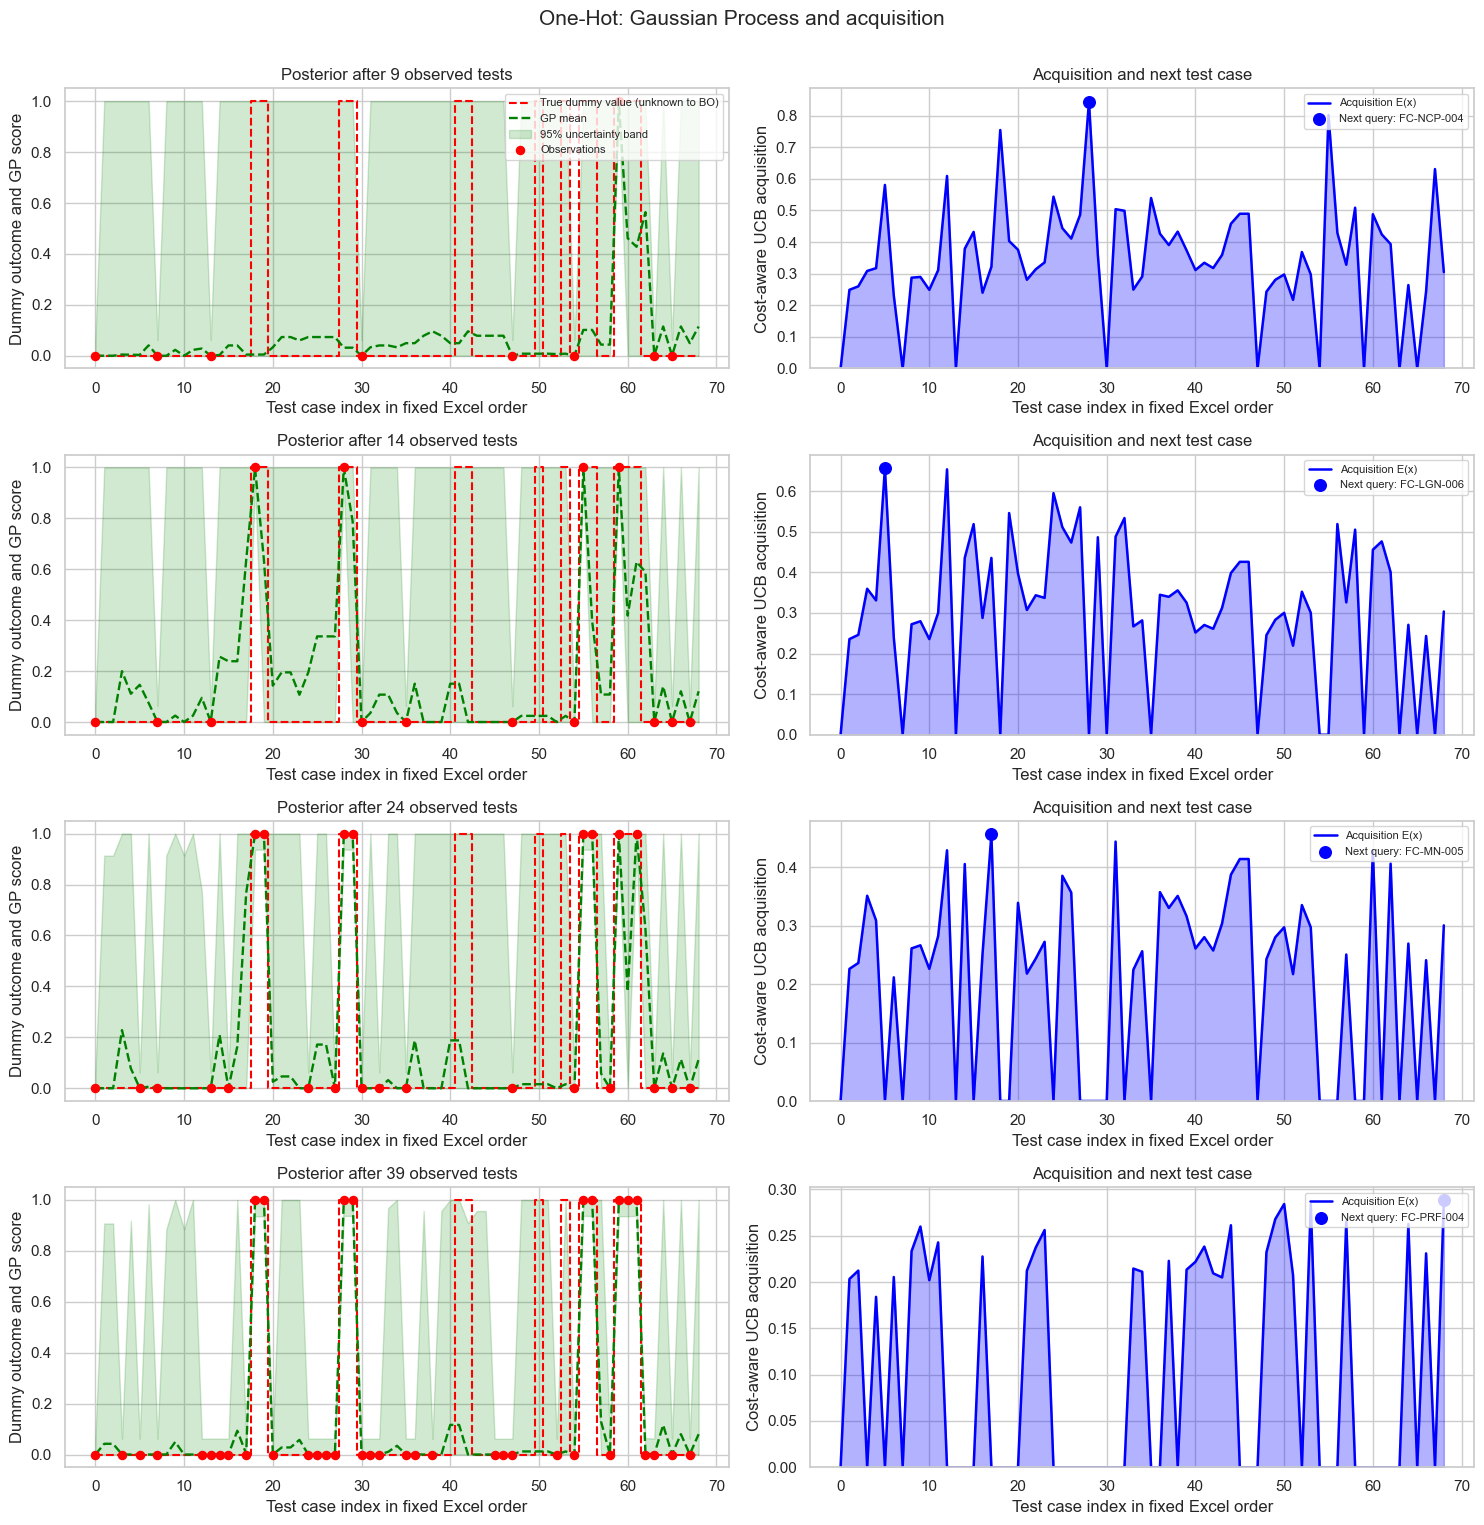

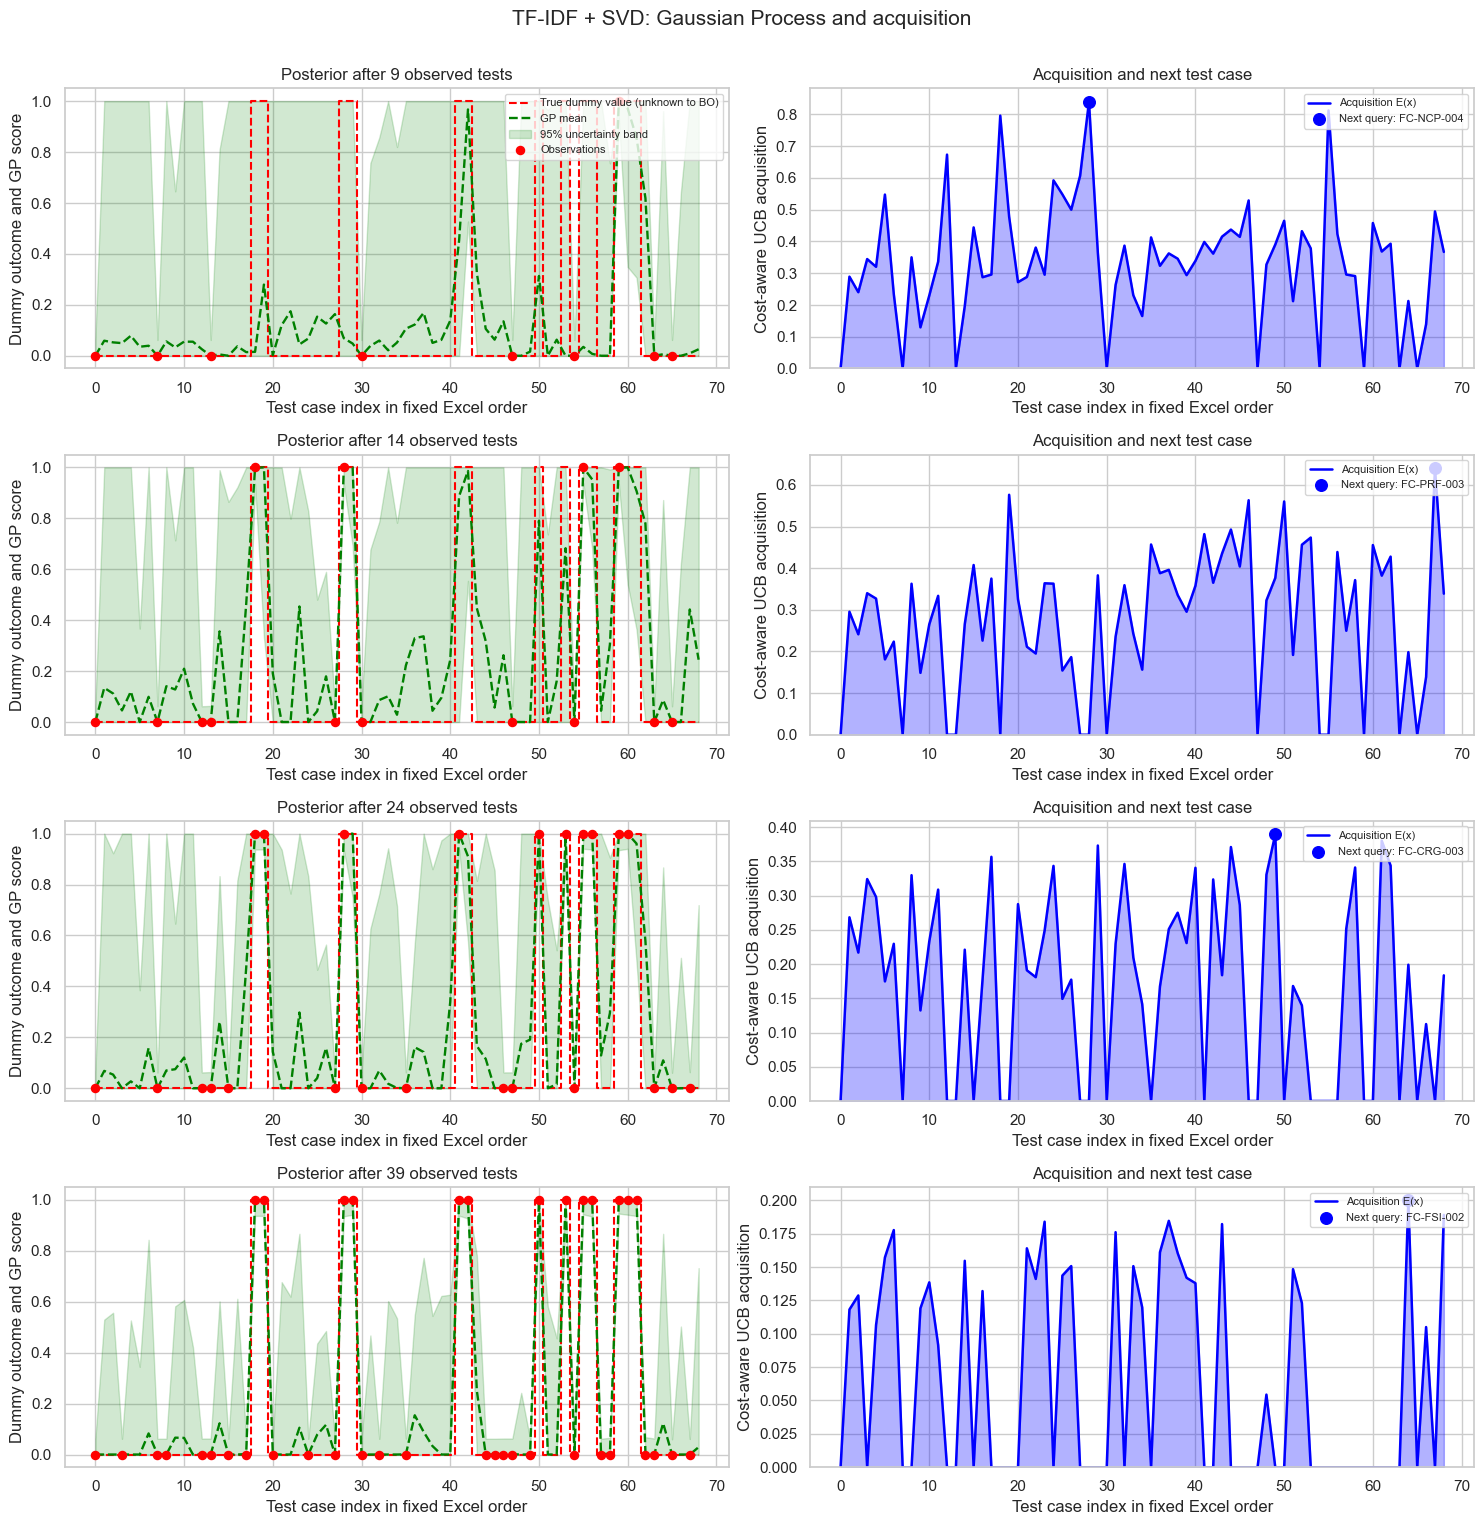

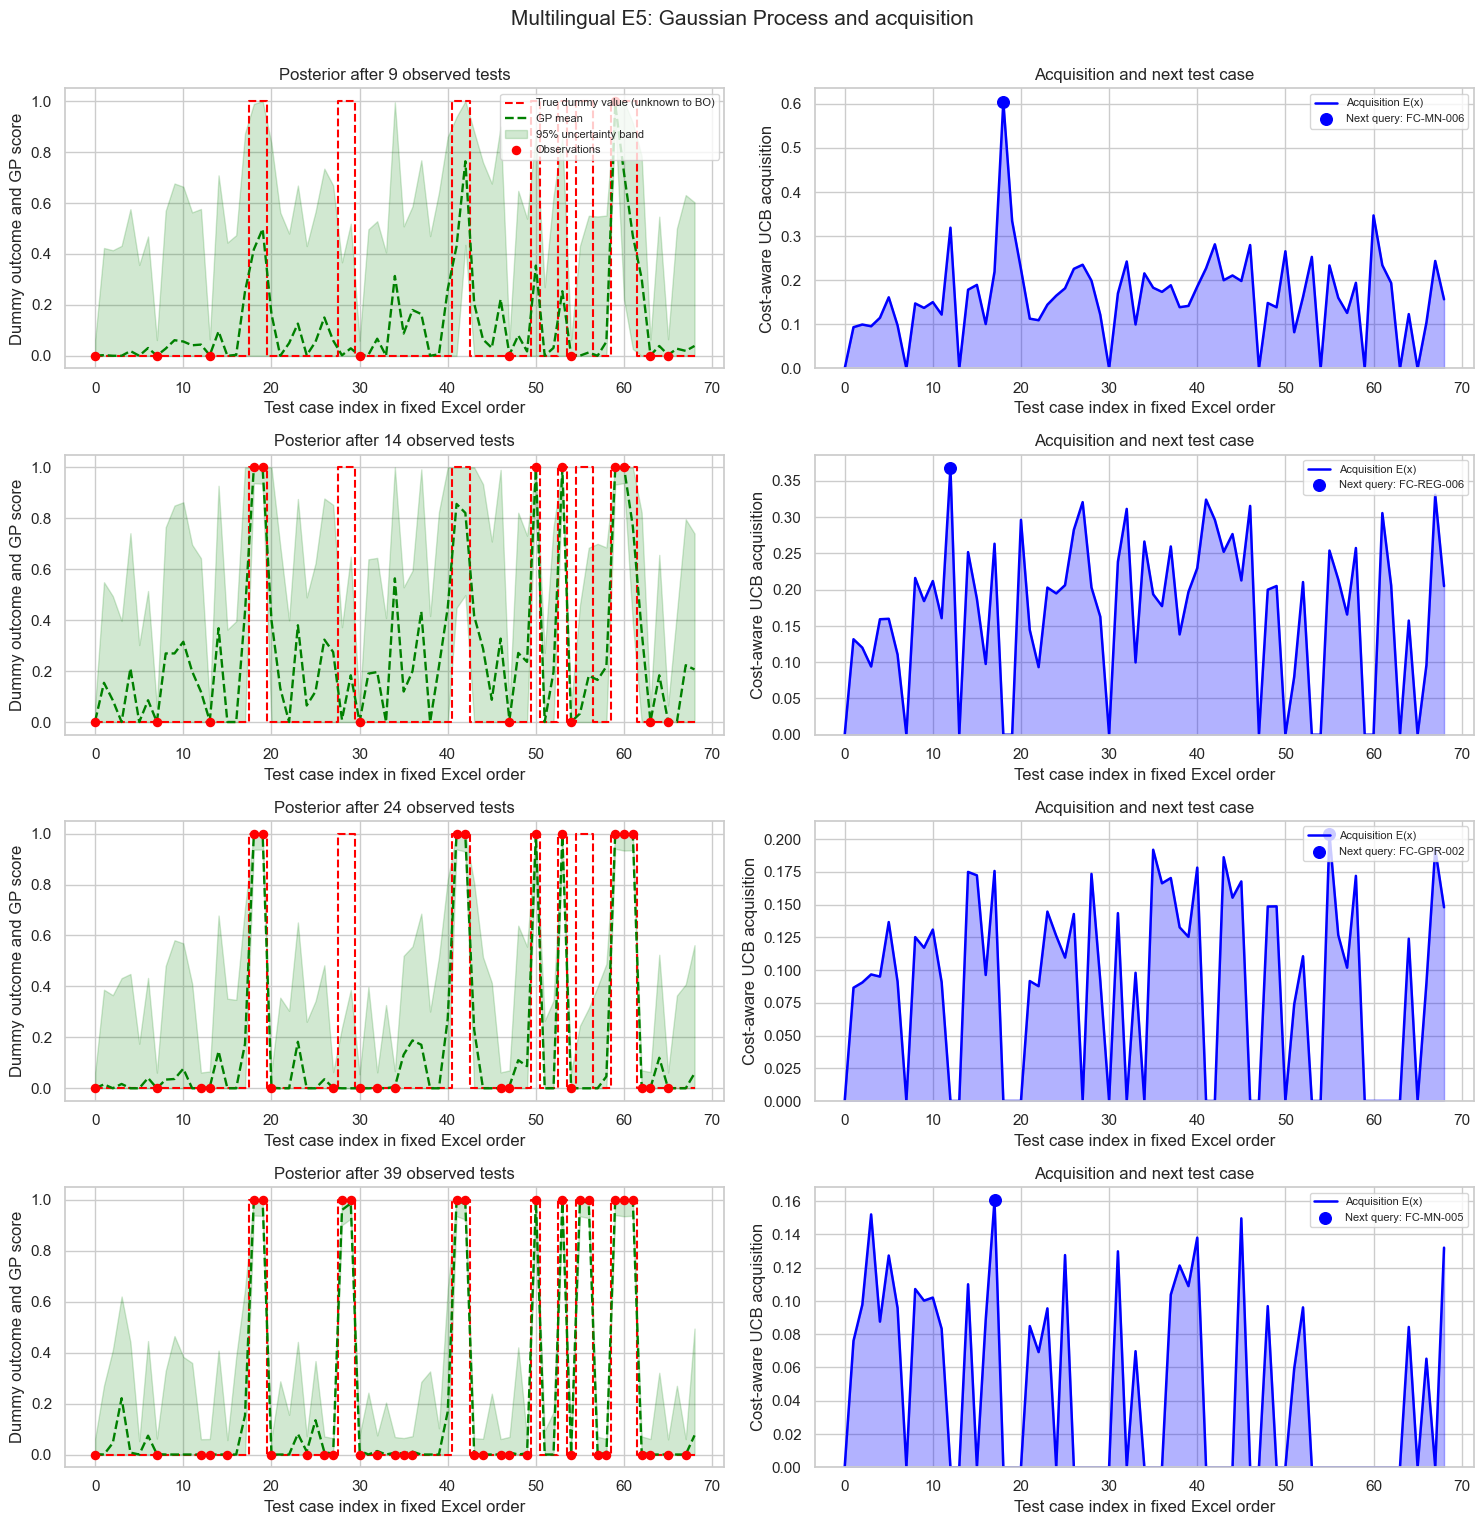

In [14]:
for method_name, method_snapshots in snapshots_by_method.items():
    fig, axes = plt.subplots(
        len(method_snapshots),
        2,
        figsize=(15, 3.8 * len(method_snapshots)),
        squeeze=False,
    )

    for row, snapshot in enumerate(method_snapshots):
        mean = snapshot["mean"]
        std = snapshot["std"]
        display_mean = np.clip(mean, 0.0, 1.0)
        display_lower = np.clip(mean - 1.96 * std, 0.0, 1.0)
        display_upper = np.clip(mean + 1.96 * std, 0.0, 1.0)
        observed = np.array(snapshot["observed_indices"], dtype=int)
        selected = snapshot["selected_index"]
        display_acquisition = np.nan_to_num(snapshot["acquisition"], nan=0.0)

        left = axes[row, 0]
        left.step(
            x_display,
            oracle,
            where="mid",
            color="red",
            linestyle="--",
            linewidth=1.5,
            label="True dummy value (unknown to BO)",
        )
        left.plot(x_display, display_mean, color="green", linestyle="--", linewidth=1.7, label="GP mean")
        left.fill_between(
            x_display,
            display_lower,
            display_upper,
            color="green",
            alpha=0.18,
            label="95% uncertainty band",
        )
        left.scatter(observed, oracle[observed], color="red", s=34, zorder=4, label="Observations")
        left.set_ylim(-0.05, 1.05)
        left.set_title(f"Posterior after {snapshot['tested_count']} observed tests")
        left.set_xlabel("Test case index in fixed Excel order")
        left.set_ylabel("Dummy outcome and GP score")
        if row == 0:
            left.legend(loc="upper right", fontsize=8)

        right = axes[row, 1]
        right.plot(x_display, display_acquisition, color="blue", linewidth=1.8, label="Acquisition E(x)")
        right.fill_between(x_display, 0, display_acquisition, color="blue", alpha=0.3)
        right.scatter(
            [selected],
            [display_acquisition[selected]],
            color="blue",
            s=70,
            zorder=4,
            label=f"Next query: {ids[selected]}",
        )
        right.set_title("Acquisition and next test case")
        right.set_xlabel("Test case index in fixed Excel order")
        right.set_ylabel("Cost-aware UCB acquisition")
        right.set_ylim(bottom=0)
        right.legend(loc="upper right", fontsize=8)

    fig.suptitle(f"{method_name}: Gaussian Process and acquisition", y=1.002, fontsize=15)
    fig.tight_layout()
    safe_name = re.sub(r"[^a-z0-9]+", "_", method_name.lower()).strip("_")
    fig.savefig(RESULT_DIR / f"iteration_snapshots_{safe_name}.png", dpi=180, bbox_inches="tight")
    plt.show()

## 12. Summary and export

The summary excludes the nine warm-start outcomes from its method-comparison metrics. A higher post-warm-start AUC means that a method found the remaining fixed dummy bugs earlier after it began making its own choices. This comparison is valid only because every method uses the same dummy outcomes.

In [15]:
warm_start_count = len(initial_indices)
warm_start_cost = float(costs[initial_indices].sum())
warm_start_bugs = int(oracle[initial_indices].sum())
summary_rows = []
for method_name, run in runs.items():
    bo_run = run.loc[run["execution_position"].gt(warm_start_count)].copy()
    bo_run["bo_selected_cumulative_bugs"] = bo_run["cumulative_bugs"] - warm_start_bugs
    bo_run["bo_selected_execution"] = bo_run["execution_position"] - warm_start_count
    bugs_by_20 = int(bo_run.loc[bo_run["execution_position"].le(20), "bo_selected_cumulative_bugs"].max())
    area = np.trapezoid(bo_run["bo_selected_cumulative_bugs"], bo_run["bo_selected_execution"])
    max_area = max(1.0, float((oracle.sum() - warm_start_bugs) * len(bo_run)))
    all_dummy_bug_cost = float(bo_run.loc[bo_run["bo_selected_cumulative_bugs"].eq(oracle.sum() - warm_start_bugs), "cumulative_cost"].iloc[0])
    summary_rows.append(
        {
            "method": method_name,
            "bo_selected_dummy_bugs_by_20_tests": bugs_by_20,
            "normalized_auc_after_warm_start": float(area / max_area),
            "additional_cost_after_warm_start": all_dummy_bug_cost - warm_start_cost,
        }
    )


summary = pd.DataFrame(summary_rows).sort_values("normalized_auc_after_warm_start", ascending=False).reset_index(drop=True)
display(summary.style.format({
    "normalized_auc_after_warm_start": "{:.3f}",
    "additional_cost_after_warm_start": "{:.1f}",
}))

for method_name, run in runs.items():
    safe_name = re.sub(r"[^a-z0-9]+", "_", method_name.lower()).strip("_")
    run.to_csv(RESULT_DIR / f"ordering_{safe_name}.csv", index=False)
summary.to_csv(RESULT_DIR / "summary.csv", index=False)

config = {
    "random_state": RANDOM_STATE,
    "kappa": KAPPA,
    "cost_exponent": COST_EXPONENT,
    "run_e5": RUN_E5,
    "e5_model_name": E5_MODEL_NAME,
    "dummy_fault_themes": DUMMY_FAULT_THEMES,
    "dummy_bug_ids": DUMMY_BUG_IDS,
    "initial_tcs_ids": cases.iloc[initial_indices]["TCS ID"].tolist(),
    "warm_start_bug_count": warm_start_bug_count,
}
with (RESULT_DIR / "experiment_config.json").open("w", encoding="utf-8") as handle:
    json.dump(config, handle, indent=2, ensure_ascii=False)

current_artifacts = [
    RESULT_DIR / "convergence.png",
    RESULT_DIR / "summary.csv",
    RESULT_DIR / "experiment_config.json",
]
for method_name in runs:
    safe_name = re.sub(r"[^a-z0-9]+", "_", method_name.lower()).strip("_")
    current_artifacts.extend(
        [
            RESULT_DIR / f"ordering_{safe_name}.csv",
            RESULT_DIR / f"iteration_snapshots_{safe_name}.png",
        ]
    )
for artifact in current_artifacts:
    if not artifact.exists():
        raise FileNotFoundError(f"Expected current artifact was not created: {artifact}")

archive_path = RESULT_DIR.parent / "bayesian_dummy_results.zip"
with zipfile.ZipFile(archive_path, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for artifact in current_artifacts:
        archive.write(artifact, arcname=artifact.name)
print("Results:", RESULT_DIR)
print("ZIP:", archive_path)
display(FileLink(str(archive_path)))

if AUTO_DOWNLOAD_IN_COLAB:
    try:
        from google.colab import files
        files.download(str(archive_path))
    except ImportError:
        pass

,method,bo_selected_dummy_bugs_by_20_tests,normalized_auc_after_warm_start,additional_cost_after_warm_start
0,Multilingual E5,8,0.853,155.0
1,TF-IDF + SVD,7,0.827,202.0
2,One-Hot,5,0.690,436.0


Results: C:\Users\radit\Project\VisualStudioProject\Skripsi\MAS AI\experiment\bayesian\results
ZIP: C:\Users\radit\Project\VisualStudioProject\Skripsi\MAS AI\experiment\bayesian\bayesian_dummy_results.zip


C:\Users\radit\Project\VisualStudioProject\Skripsi\MAS AI\experiment\bayesian\bayesian_dummy_results.zip

## 13. How to read the result

A method performs better in this controlled experiment when its convergence curve rises earlier. That result only shows how well each representation matches the fixed dummy pattern. It does not prove that the same method will find real application bugs earlier. A later experiment can replace the dummy oracle with real execution outcomes while keeping the same selection loop and metrics.
